In [ ]:
# Environment setup and package check
import sys
import warnings
warnings.filterwarnings('ignore')

def check_package(package_name):
    try:
        __import__(package_name)
        return True
    except ImportError:
        return False

required_packages = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'networkx', 'scipy']
missing_packages = [pkg for pkg in required_packages if not check_package(pkg)]

if missing_packages:
    print("⚠️ Missing required packages:", ', '.join(missing_packages))
    print("Please install them using:")
    print(f"pip install {' '.join(missing_packages)}")
    sys.exit(1)
else:
    print("✅ All required packages are installed")

# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from norton_bass_network import NortonBassNetworkModel

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("\n✅ Environment setup complete")


In [3]:
# Initialize model with 3 generations
model = NortonBassNetworkModel(n_generations=3, network_size=500)

# Create small-world network
model.create_network(network_type='small_world', k=4, p=0.3)

# Generate sample data
print("Generating sample data...")
sample_data = model.generate_sample_data(periods=50, noise_level=0.05)

# Display first few rows
print("\nSample adoption data:")
print(sample_data.head())


Generating sample data...

Sample adoption data:
   Generation_1  Generation_2  Generation_3  Time  Total_Adoption
0      5.175138     25.328328     41.050099   0.0        0.000000
1      0.000000     52.217128     27.124134   0.1        1.010686
2      8.783742      0.000000      1.749257   0.2        2.035641
3     18.943094     15.395611      0.000000   0.3        3.075036
4      1.689456      0.000000     20.482384   0.4        4.129040


In [ ]:
# Analyze network structure
network_analysis = model.analyze_network_effects()

# Print key metrics
print("Network Analysis Results:")
print(f"Network size: {network_analysis['network_size']} nodes")
print(f"Network density: {network_analysis['density']:.4f}")
print(f"Average clustering: {network_analysis['average_clustering']:.4f}")
print(f"Average influence: {network_analysis['avg_influence']:.4f}")
print(f"Average degree: {network_analysis['avg_degree']:.2f}")

if isinstance(network_analysis['diameter'], (int, float)):
    print(f"Network diameter: {network_analysis['diameter']}")
if isinstance(network_analysis['average_path_length'], (int, float)):
    print(f"Average path length: {network_analysis['average_path_length']:.2f}")


In [4]:
# Estimate parameters
print("Estimating model parameters...")
estimated_params = model.estimate_parameters(
    sample_data,
    method='mle',
    max_iter=50,
    tol=1e-3
)

# Print estimated parameters
print("\nEstimated Parameters:")
for gen in range(model.n_generations):
    print(f"\nGeneration {gen + 1}:")
    print(f"  Market Potential (m): {estimated_params[f'm_{gen}']:.0f}")
    print(f"  Innovation Coeff (p): {estimated_params[f'p_{gen}']:.4f}")
    print(f"  Imitation Coeff (q): {estimated_params[f'q_{gen}']:.4f}")
    if gen > 0:
        print(f"  Substitution Rate: {estimated_params[f'sub_{gen}_{gen-1}']:.4f}")


Estimating model parameters...
Starting parameter estimation...
differential_evolution step 1: f(x)= 7780560384.587771
differential_evolution step 2: f(x)= 5841977935.628472
differential_evolution step 3: f(x)= 3884581330.780779
differential_evolution step 4: f(x)= 3754355983.91343
differential_evolution step 5: f(x)= 3754355983.91343
differential_evolution step 6: f(x)= 3754355983.91343
differential_evolution step 7: f(x)= 3754355983.91343
differential_evolution step 8: f(x)= 1334594660.745896
differential_evolution step 9: f(x)= 1334594660.745896
differential_evolution step 10: f(x)= 1334594660.745896
differential_evolution step 11: f(x)= 1120804002.5416
differential_evolution step 12: f(x)= 1120804002.5416
differential_evolution step 13: f(x)= 165239319.68985647
differential_evolution step 14: f(x)= 165239319.68985647
differential_evolution step 15: f(x)= 165239319.68985647
differential_evolution step 16: f(x)= 120371304.40170777
differential_evolution step 17: f(x)= 120371304.40170

In [5]:
# Generate forecasts
print("Generating forecasts...")
forecast = model.forecast(periods=60)

# Calculate total adoption
total_adoption = forecast['Total_Adoption'].iloc[-1]
print(f"\nTotal projected adoption at t=60: {total_adoption:.0f}")

# Find peak adoption times
for i in range(model.n_generations):
    col = f'Generation_{i+1}'
    if col in forecast.columns:
        peak_adoption = forecast[col].max()
        peak_time = forecast.loc[forecast[col].idxmax(), 'Time']
        print(f"\nGeneration {i+1}:")
        print(f"  Peak adoption: {peak_adoption:.1f}")
        print(f"  Peak time: t={peak_time:.1f}")


Generating forecasts...

Total projected adoption at t=60: 1117

Generation 1:
  Peak adoption: 254.8
  Peak time: t=15.6

Generation 2:
  Peak adoption: 443.2
  Peak time: t=24.4

Generation 3:
  Peak adoption: 419.1
  Peak time: t=59.9


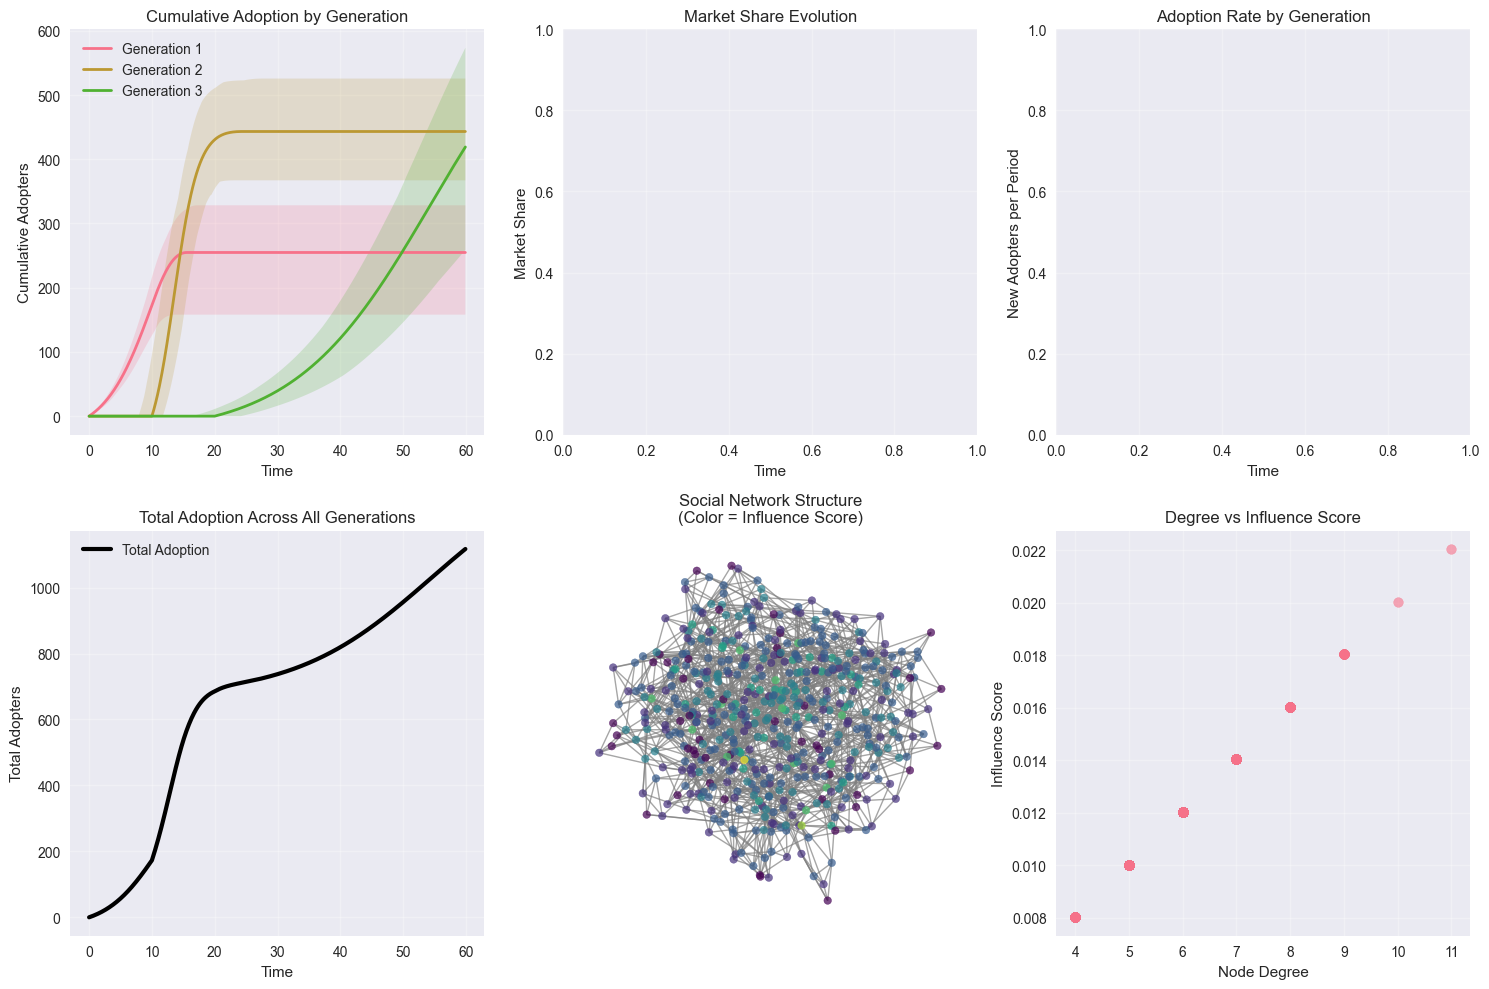


Key Insights:
1. Network Structure:
   - Small-world network with 500 nodes
   - Clustering coefficient: 0.230
   - Network density: 0.012

2. Adoption Patterns:
   - Total projected adoption: 1117
   - Multiple generations with substitution effects
   - Network-influenced diffusion speed

3. Model Performance:
   - Parameters estimated using MLE
   - Generation 1 peak: 255 at t=15.6
   - Generation 2 peak: 443 at t=24.4
   - Generation 3 peak: 419 at t=59.9


In [8]:
# Create visualizations with error handling
try:
    # Plot diffusion curves
    fig = model.plot_diffusion_curves(forecast, show_network_metrics=True)
    plt.show()
    
    # Get fresh network analysis (in case previous analysis is not available)
    current_analysis = model.analyze_network_effects()
    
    # Print insights
    print("\nKey Insights:")
    
    print("1. Network Structure:")
    print(f"   - Small-world network with {current_analysis.get('network_size', 'N/A')} nodes")
    print(f"   - Clustering coefficient: {current_analysis.get('average_clustering', 0):.3f}")
    print(f"   - Network density: {current_analysis.get('density', 0):.3f}")
    
    print("\n2. Adoption Patterns:")
    if 'Total_Adoption' in forecast.columns:
        final_adoption = forecast['Total_Adoption'].iloc[-1]
        print(f"   - Total projected adoption: {final_adoption:.0f}")
    print("   - Multiple generations with substitution effects")
    print("   - Network-influenced diffusion speed")
    
    print("\n3. Model Performance:")
    print("   - Parameters estimated using MLE")
    for i in range(model.n_generations):
        gen_col = f'Generation_{i+1}'
        if gen_col in forecast.columns:
            max_val = forecast[gen_col].max()
            max_time = forecast.loc[forecast[gen_col].idxmax(), 'Time']
            print(f"   - Generation {i+1} peak: {max_val:.0f} at t={max_time:.1f}")
            
except Exception as e:
    print(f"Error generating visualizations: {str(e)}")
    print("Please ensure you have run all previous cells in order.")
